# Main daily data EDA

This is a self-contained EDA notebook. It does not require SQLite, SQL, the Kalshi API, or the extraction pipeline to be running.

It works only with the CSV and JSON outputs created by `daily_data_diagnostic.ipynb`.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")

project_roots = [Path.cwd(), *Path.cwd().parents]
project_roots += [
    path / "daily_export"
    for path in project_roots
    if (path / "daily_export").is_dir()
]
PROJECT_ROOT = next(
    (
        path
        for path in project_roots
        if (path / "data/demo/export_summary.json").exists()
    ),
    Path.cwd(),
)
# DATA_DIR = PROJECT_ROOT / "data" / "demo"
# To inspect the filtered view instead, use:
DATA_DIR = PROJECT_ROOT / "data" / "demo_filtered"

METADATA_PATH = DATA_DIR / "main_market_metadata.csv"
CANDLES_PATH = DATA_DIR / "main_daily_candles.csv"
SUMMARY_PATH = DATA_DIR / "export_summary.json"

In [2]:
metadata_text_columns = [
    "market_id", "market_ticker", "event_ticker", "series_ticker",
    "market_question", "market_subtitle", "yes_subtitle", "no_subtitle",
    "market_rules", "event_question", "event_subtitle", "series_title",
    "series_category", "series_frequency", "market_status",
    "market_result", "download_status",
]
metadata = pd.read_csv(
    METADATA_PATH,
    dtype={column: "string" for column in metadata_text_columns},
)


for column in [
    "history_start_ts", "history_end_ts",
    "first_observation_ts", "last_observation_ts",
]:
    metadata[column] = pd.to_datetime(
        pd.to_numeric(metadata[column], errors="coerce"),
        unit="s",
        utc=True,
        errors="coerce",
    )

for column in [
    "passes_volume_filter", "passes_lifetime_filter", "passes_both_filters",
    "volume_fp", "lifetime_days", "expected_daily_rows",
    "received_daily_rows", "actual_candles_exported",
]:
    metadata[column] = pd.to_numeric(metadata[column], errors="coerce")
metadata.sample(5)


,market_id,market_ticker,event_ticker,series_ticker,market_question,market_subtitle,yes_subtitle,no_subtitle,market_rules,event_question,event_subtitle,series_title,series_category,series_frequency,market_status,market_result,open_time,close_time,passes_volume_filter,passes_lifetime_filter,passes_both_filters,volume_fp,lifetime_days,history_start_ts,history_end_ts,expected_daily_rows,received_daily_rows,first_observation_ts,last_observation_ts,download_status,actual_candles_exported
7410,kalshi:KXWTIMIN-26DEC31-T50,KXWTIMIN-26DEC31-T50,KXWTIMIN-26DEC31,KXWTIMIN,"Will the minimum WTI front month settle price reach $50 by Dec 31, 2026?",49.99 or below,49.99 or below,49.99 or below,If ICE reports that the minimum price of oil (as defined exclusively by the set of WTI front-month settle prices) is...,How low will oil (WTI) get by end of year?,In 2026,WTI oil low,Commodities,annual,active,<NA>,2026-04-08T14:00:00Z,2026-12-31T19:30:00Z,1,1,1,31768.31,267.229167,2026-04-08 14:00:00+00:00,2026-08-19 22:09:55+00:00,135,128,2026-04-09 04:00:00+00:00,2026-08-19 04:00:00+00:00,success,128
2432,kalshi:KXGBT55OY-27-NA-15,KXGBT55OY-27-NA-15,KXGBT55OY-27,KXGBT55OY,Will Output Token Price of OpenAI GPT 5.5 be at or below $15/MTok in 2026?,<NA>,$15/MTok or below,$15/MTok or below,"If the Output Token Price of OpenAI GPT 5.5 on https://openai.com/api/pricing/ is at or below $15 in 2026, then the ...",How low will the OpenAI GPT 5.5 output token price get in 2026?,in 2026,GPT 5.5 Input Token,Commodities,annual,active,<NA>,2026-06-08T19:00:00Z,2027-04-01T15:00:00Z,1,1,1,13688.66,296.833333,2026-06-08 19:00:00+00:00,2026-08-19 22:09:55+00:00,74,64,2026-06-09 04:00:00+00:00,2026-08-19 04:00:00+00:00,success,64
4522,kalshi:KXPAYROLLS-26JUL-T60000,KXPAYROLLS-26JUL-T60000,KXPAYROLLS-26JUL,KXPAYROLLS,Will above 60000 jobs be added in July 2026?,"60,000","Above 60,000","Above 60,000",If the increase in total non-farm payroll employment is above 60000 as reported by the Bureau of Labor Statistics Mo...,Jobs numbers in Jul 2026?,In Jul 2026,Jobs numbers,Economics,monthly,finalized,no,2025-10-13T14:00:00Z,2026-08-07T12:29:00Z,1,1,1,48446.56,297.936806,2025-10-13 14:00:00+00:00,2026-08-07 12:29:00+00:00,299,210,2025-10-14 04:00:00+00:00,2026-08-07 04:00:00+00:00,success,210
3563,kalshi:KXLIUSAWINNERS-26-SEA,KXLIUSAWINNERS-26-SEA,KXLIUSAWINNERS-26,KXLIUSAWINNERS,Will Sean win Love Island USA Season 8?,Sean:: @parm3_sean,Sean,Sean,"If Sean is officially declared the winner of Love Island USA Season 8, then the market resolves to Yes.",Love Island USA S8: Winners,Love Island USA Season 8,who will win love island USA,Entertainment,one_off,finalized,no,2026-05-29T00:15:00Z,2026-07-13T02:44:45Z,1,1,1,41878.26,45.103993,2026-05-29 00:15:00+00:00,2026-07-13 02:44:45+00:00,47,45,2026-05-29 04:00:00+00:00,2026-07-12 04:00:00+00:00,success,45
5283,kalshi:KXRT-ICE-50,KXRT-ICE-50,KXRT-ICE,KXRT,Ice Cream Man Rotten Tomatoes score?,Above 50,Above 50,Above 50,"If Ice Cream Man has a Tomatometer score of above 50 on Aug 10, 2026 at 10:00 AM ET, then the market resolves to Yes.",Ice Cream Man · Rotten Tomatoes score,Ice Cream Man,Rotten Tomatoes Scores,Entertainment,custom,finalized,no,2026-07-28T02:20:00Z,2026-08-10T14:00:00Z,1,1,1,23412.88,13.486111,2026-07-28 02:20:00+00:00,2026-08-10 14:00:00+00:00,15,14,2026-07-28 04:00:00+00:00,2026-08-10 04:00:00+00:00,success,14


In [3]:
metadata.download_status.value_counts(dropna=False)

download_status
success    7283
empty       262
Name: count, dtype: int64[pyarrow]

In [4]:
metadata = metadata[metadata.download_status == "success"].reset_index(drop=True)
main_metacols = ['market_id','market_question', 'volume_fp', 'lifetime_days', 'market_result']
metadata[main_metacols].sample(10)

,market_id,market_question,volume_fp,lifetime_days,market_result
1767,kalshi:KXEMERCUTS-26-T0,Will the Fed cut rates 0 times at emergency meetings?,245264.94,360.082639,<NA>
3074,kalshi:KXIPOANTHROPIC-DATE-26DEC01,When will Anthropic officially announce an IPO?,48582.16,243.624306,<NA>
6895,kalshi:KXWCFIRSTSONG-26JUL20-DAI,"Will Dai Dai be the first song performed by any of Madonna, Shakira, or BTS (any member of BTS) during the FIFA Worl...",372362.33,32.881655,no
1239,kalshi:KXCRYPTOSTRUCTURE-27JAN-27OCT01,"Will a crypto market structure bill become law before Oct 1, 2027?",35121.53,450.000000,<NA>
4598,kalshi:KXPRIMARYMOV-GOVGANOMR262R-RJAC-P1,Will the margin of victory for Rick Jackson in the 2026 Georgia Republican gubernatorial runoff be between 0% and 3%?,24330.25,29.031794,no
2227,kalshi:KXFLPRIMARY-21D26-BTAY,Will Bernard Taylor be the Democratic nominee for FL-21?,12069.05,386.658333,<NA>
2370,kalshi:KXGDPYEAR-35-B5.3,GDP growth in 2035?,10111.99,3502.561806,<NA>
6105,kalshi:KXTRUMPSAY-26AUG10-LAND,"Will Trump say ""Landslide"" before Aug 10, 2026?",59980.53,7.416667,yes
1922,kalshi:KXFED-26SEP-T4.25,"Will the upper bound of the federal funds rate be above 4.25% following the Fed's Sep 16, 2026 meeting?",17294.45,406.142361,<NA>
1700,kalshi:KXECONSTATCORECPIYOY-26JUN-T2.2,CPI core year-over-year in Jun 2026?,32948.00,210.895139,no


In [5]:
candles_text_columns = ["market_id", "market_ticker", "series_ticker"]
candles = pd.read_csv(
    CANDLES_PATH,
    dtype={column: "string" for column in candles_text_columns},
)

with SUMMARY_PATH.open("r", encoding="utf-8") as handle:
    export_summary = json.load(handle)

for column in ["open_time", "close_time"]:
    metadata[column] = pd.to_datetime(
        metadata[column], utc=True, errors="coerce"
    )

candles["end_period_ts"] = pd.to_numeric(
    candles["end_period_ts"], errors="coerce"
)
candles["date_utc"] = pd.to_datetime(
    candles["date_utc"], utc=True, errors="coerce"
)

for column in [
    "price_open", "price_low", "price_high", "price_close",
    "price_mean", "price_previous", "yes_bid_close", "yes_ask_close",
    "volume", "open_interest",
]:
    candles[column] = pd.to_numeric(candles[column], errors="coerce")
candles.sample(5)

,market_id,market_ticker,series_ticker,end_period_ts,date_utc,price_open,price_low,price_high,price_close,price_mean,price_previous,yes_bid_close,yes_ask_close,volume,open_interest
142562,kalshi:KXBRPRES-26-MB,KXBRPRES-26-MB,KXBRPRES,1759377600,2025-10-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.05,0.11,0.00,0.00
73042,kalshi:KX2028RRUN-28-VRAM,KX2028RRUN-28-VRAM,KX2028RRUN,1768626000,2026-01-17 00:00:00+00:00,0.35,0.35,0.35,0.35,0.3500,0.35,0.31,0.35,14.00,1744.00
721045,kalshi:KXTRUMPADMINLEAVE-26DEC31-MOZ,KXTRUMPADMINLEAVE-26DEC31-MOZ,KXTRUMPADMINLEAVE,1775620800,2026-04-08 00:00:00+00:00,0.23,0.21,0.24,0.21,0.2109,0.20,0.19,0.22,106.00,4628.00
152108,kalshi:KXCAVA-26AUGREST-475,KXCAVA-26AUGREST-475,KXCAVA,1780545600,2026-06-04 00:00:00+00:00,0.94,0.94,0.94,0.94,0.9400,0.93,0.93,0.97,38.00,1121.35
587289,kalshi:KXRAINDALM-26JUL-1,KXRAINDALM-26JUL-1,KXRAINDALM,1783224000,2026-07-05 00:00:00+00:00,0.64,0.64,0.65,0.65,0.6472,0.65,0.64,0.65,430.91,1841.12


## 1. Snapshot overview

This is a compact inventory of the prepared snapshot and its time range. We first establish what was actually downloaded before interpreting individual fields.

In [6]:
overview = pd.DataFrame([
    {"metric": "market metadata rows", "value": len(metadata)},
    {"metric": "markets with candles", "value": candles["market_id"].nunique()},
    {"metric": "events represented", "value": metadata["event_ticker"].nunique()},
    {"metric": "series represented", "value": metadata["series_ticker"].nunique()},
    {"metric": "daily candle rows", "value": len(candles)},
    {"metric": "first candle date UTC", "value": candles["date_utc"].min()},
    {"metric": "last candle date UTC", "value": candles["date_utc"].max()},
    {"metric": "markets with zero candles", "value": int(
        metadata["actual_candles_exported"].eq(0).sum()
    )},
    {"metric": "run status", "value": export_summary["run_status"]},
])
display(overview)

,metric,value
0,market metadata rows,7283
1,markets with candles,7283
2,events represented,2015
3,series represented,1369
4,daily candle rows,860012
5,first candle date UTC,2023-10-24 00:00:00+00:00
6,last candle date UTC,2026-08-19 00:00:00+00:00
7,markets with zero candles,0
8,run status,success


## 4. Calendar coverage

The calendar view shows when observations are present and whether coverage is steady or concentrated on particular dates. We look at both the number of rows and total daily volume.

In [7]:
daily_summary = (
    candles.groupby("date_utc")
    .agg(
        markets=("market_id", "nunique"),
        candle_rows=("market_id", "size"),
        price_close_valid=("price_close", "count"),
        bid_close_valid=("yes_bid_close", "count"),
        ask_close_valid=("yes_ask_close", "count"),
        total_volume=("volume", "sum"),
        mean_open_interest=("open_interest", "mean"),
    )
    .reset_index()
    .sort_values("date_utc")
)
display(daily_summary.sort_values(
    ["markets", "candle_rows"], ascending=False
).head(20))

,date_utc,markets,candle_rows,price_close_valid,bid_close_valid,ask_close_valid,total_volume,mean_open_interest
930,2026-07-11 00:00:00+00:00,4146,4146,2552,4146,4146,11586908.62,83817.062964
929,2026-07-10 00:00:00+00:00,4144,4144,2529,4144,4144,8460487.93,85221.230355
908,2026-06-19 00:00:00+00:00,4136,4136,2622,4136,4136,9563877.21,80680.091296
900,2026-06-11 00:00:00+00:00,4081,4081,2451,4081,4081,7122654.77,74979.568880
915,2026-06-26 00:00:00+00:00,4015,4015,2525,4015,4015,13351487.30,85634.596448
907,2026-06-18 00:00:00+00:00,3973,3973,2801,3973,3973,11940723.61,82566.220345
901,2026-06-12 00:00:00+00:00,3970,3970,2460,3970,3970,7788937.96,74501.045431
928,2026-07-09 00:00:00+00:00,3960,3960,2622,3960,3960,12403967.17,87565.387990
936,2026-07-17 00:00:00+00:00,3949,3949,2557,3949,3949,11041612.12,92027.080757
906,2026-06-17 00:00:00+00:00,3948,3948,2595,3948,3948,9883706.21,81420.399557


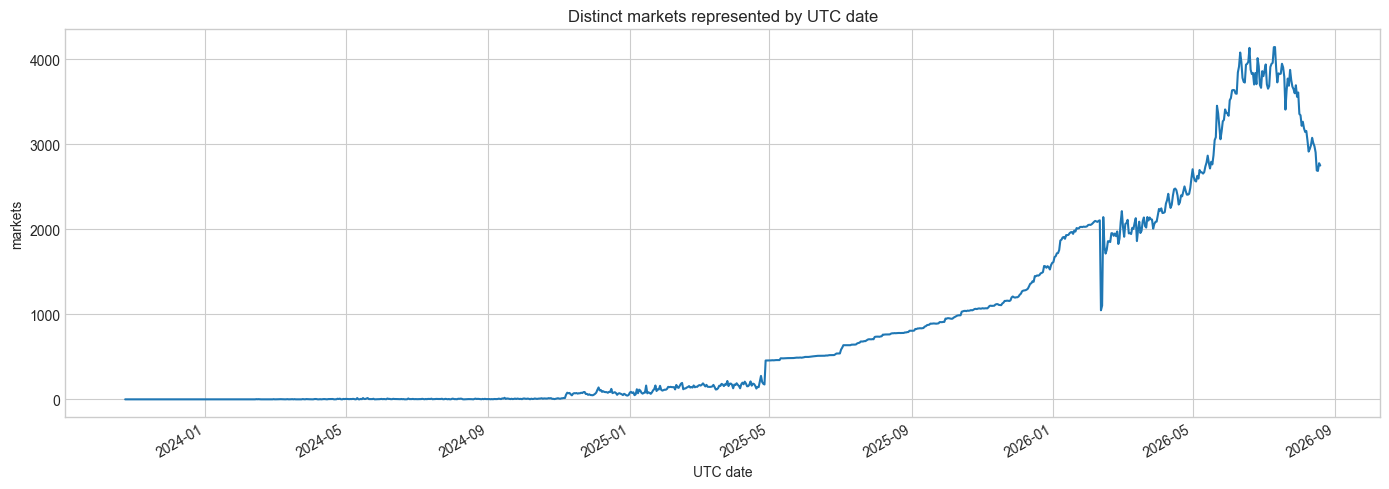

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
daily_summary.plot(
    x="date_utc",
    y="markets",
    ax=ax,
    color="tab:blue",
    title="Distinct markets represented by UTC date",
    legend=False,
)
ax.set_xlabel("UTC date")
ax.set_ylabel("markets")
plt.tight_layout()
plt.show()

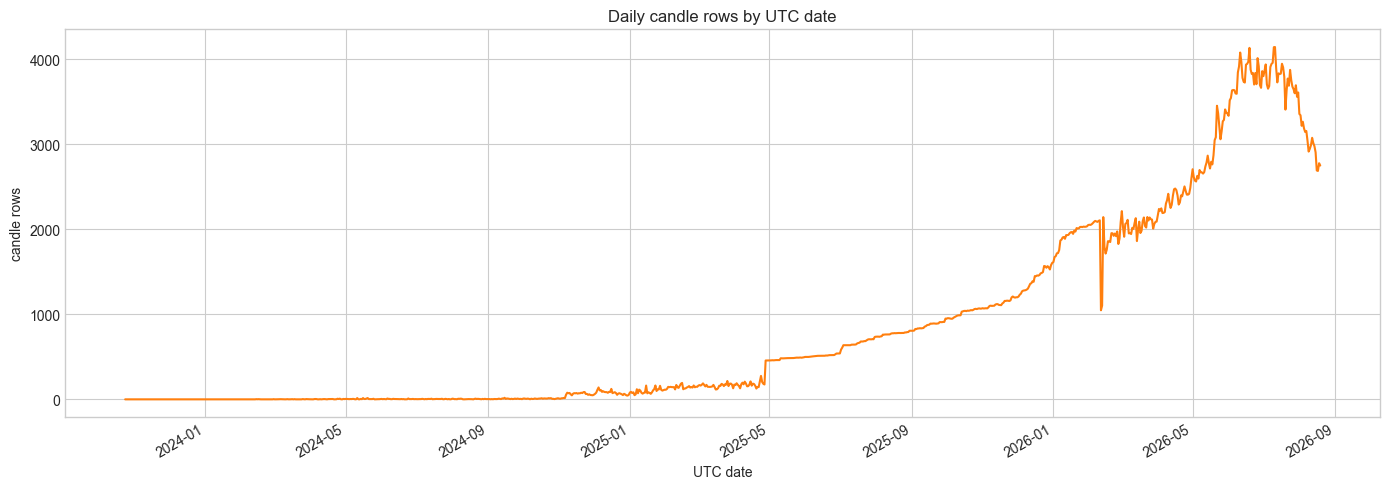

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
daily_summary.plot(
    x="date_utc",
    y="candle_rows",
    ax=ax,
    color="tab:orange",
    title="Daily candle rows by UTC date",
    legend=False,
)
ax.set_xlabel("UTC date")
ax.set_ylabel("candle rows")
plt.tight_layout()
plt.show()

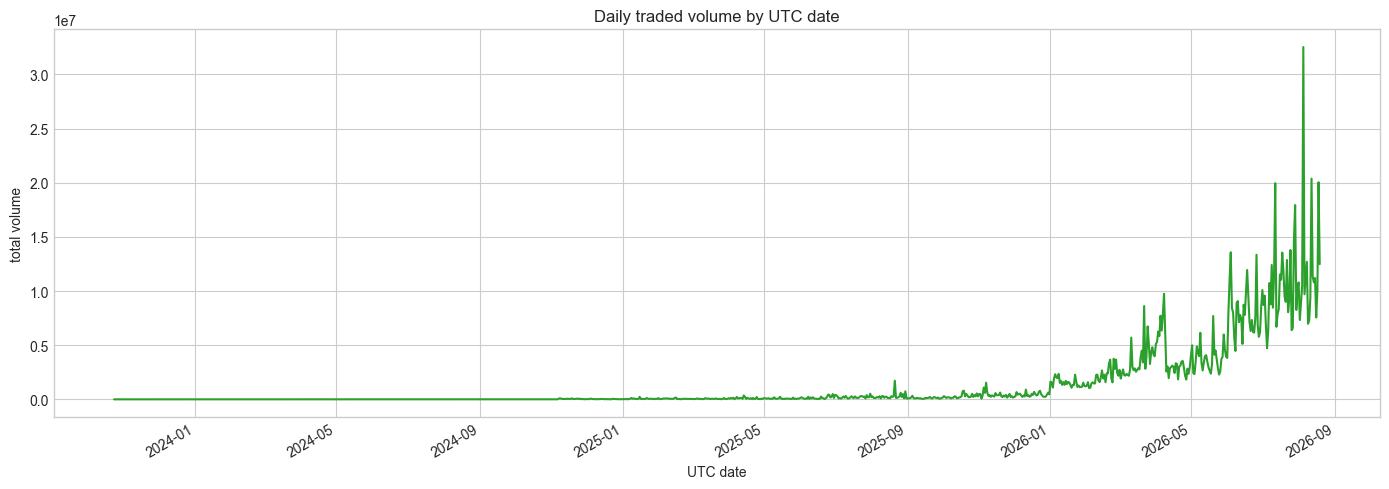

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

daily_summary.plot(
    x="date_utc",
    y="total_volume",
    ax=ax,
    color="tab:green",
    title="Daily traded volume by UTC date",
    legend=False,
)

ax.set_xlabel("UTC date")
ax.set_ylabel("total volume")
plt.tight_layout()
plt.show()

## 5. Market dates and question context

These checks connect coverage to actual market lifecycles and bring the question text back next to the quantitative data.

In [11]:
market_activity = (
    candles.groupby("market_id")
    .agg(
        observed_days=("date_utc", "nunique"),
        price_close_days=("price_close", "count"),
        total_volume=("volume", "sum"),
        first_candle=("date_utc", "min"),
        last_candle=("date_utc", "max"),
    )
    .reset_index()
)

question_context = (
    metadata.merge(market_activity, on="market_id", how="inner", validate="one_to_one")
    .sort_values(
        ["price_close_days", "total_volume"],
        ascending=False,
    )
    [[
        "market_id", "market_ticker", "market_question",
        "event_question", "series_title", "series_category",
        "open_time", "close_time", "first_candle", "last_candle",
        "observed_days", "price_close_days", "total_volume",
        "market_result",
    ]]
    .head(15)
)
display(question_context)

,market_id,market_ticker,market_question,event_question,series_title,series_category,open_time,close_time,first_candle,last_candle,observed_days,price_close_days,total_volume,market_result
4458,kalshi:KXPRESNOMD-28-GN,KXPRESNOMD-28-GN,Will Gavin Newsom be the Democratic Presidential nominee in 2028?,2028 Democratic presidential nominee,Democratic Primary winner,Elections,2024-11-06 15:00:00+00:00,2028-11-07 15:00:00+00:00,2024-11-07 00:00:00+00:00,2026-08-19 00:00:00+00:00,645,644,9117593.23,<NA>
4505,kalshi:KXPRESNOMR-28-JDV,KXPRESNOMR-28-JDV,Will J.D. Vance be the nominee for the Presidency for the Republican party?,2028 Republican presidential nominee,Republican Primary winner,Elections,2024-11-06 15:00:00+00:00,2028-11-07 15:00:00+00:00,2024-11-07 00:00:00+00:00,2026-08-19 00:00:00+00:00,646,637,4080244.37,<NA>
4470,kalshi:KXPRESNOMD-28-JS,KXPRESNOMD-28-JS,Will Josh Shapiro be the Democratic Presidential nominee in 2028?,2028 Democratic presidential nominee,Democratic Primary winner,Elections,2024-11-06 15:00:00+00:00,2028-11-07 15:00:00+00:00,2024-11-07 00:00:00+00:00,2026-08-19 00:00:00+00:00,630,618,4624761.64,<NA>
2976,kalshi:KXIMPEACH-29-JAN20,KXIMPEACH-29-JAN20,"Will the President be impeached before Jan 20, 2029?",Will President Trump be impeached during his term?,President impeached,Politics,2024-11-08 15:00:00+00:00,2029-01-20 15:00:00+00:00,2024-11-09 00:00:00+00:00,2026-08-19 00:00:00+00:00,632,612,501680.94,<NA>
4448,kalshi:KXPRESNOMD-28-AOC,KXPRESNOMD-28-AOC,Will Alexandria Ocasio-Cortez be the Democratic Presidential nominee in 2028?,2028 Democratic presidential nominee,Democratic Primary winner,Elections,2024-11-06 15:00:00+00:00,2028-11-07 15:00:00+00:00,2024-11-07 00:00:00+00:00,2026-08-19 00:00:00+00:00,610,603,7965683.06,<NA>
4495,kalshi:KXPRESNOMR-28-DJT,KXPRESNOMR-28-DJT,Will Donald J. Trump be the nominee for the Presidency for the Republican party?,2028 Republican presidential nominee,Republican Primary winner,Elections,2024-11-06 15:00:00+00:00,2028-11-07 15:00:00+00:00,2024-11-07 00:00:00+00:00,2026-08-19 00:00:00+00:00,626,602,3991303.50,<NA>
4480,kalshi:KXPRESNOMD-28-PB,KXPRESNOMD-28-PB,Will Pete Buttigieg be the Democratic Presidential nominee in 2028?,2028 Democratic presidential nominee,Democratic Primary winner,Elections,2024-11-06 15:00:00+00:00,2028-11-07 15:00:00+00:00,2024-11-07 00:00:00+00:00,2026-08-19 00:00:00+00:00,605,599,5559882.05,<NA>
2573,kalshi:KXGREENLAND-29,KXGREENLAND-29,Will Trump buy Greenland?,Will Trump buy at least part of Greenland?,Greenland purchase,Politics,2024-12-21 15:00:00+00:00,2029-01-20 15:00:00+00:00,2024-12-22 00:00:00+00:00,2026-08-19 00:00:00+00:00,604,599,3467499.78,<NA>
7276,kalshi:TESLAOPTIMUS-26DEC31,TESLAOPTIMUS-26DEC31,Tesla Optimus on sale before 2027?,Tesla Optimus released this year?,Tesla Optimus sale,Science and Technology,2024-02-09 14:30:00+00:00,2026-12-31 04:59:00+00:00,2024-02-10 00:00:00+00:00,2026-08-19 00:00:00+00:00,721,595,347637.24,<NA>
4473,kalshi:KXPRESNOMD-28-KH,KXPRESNOMD-28-KH,Will Kamala Harris be the Democratic Presidential nominee in 2028?,2028 Democratic presidential nominee,Democratic Primary winner,Elections,2024-11-06 15:00:00+00:00,2028-11-07 15:00:00+00:00,2024-11-07 00:00:00+00:00,2026-08-19 00:00:00+00:00,611,592,6760129.46,<NA>


In [12]:
def plot_price_mean_for_market(
    market_id, ax=None, figsize=(14, 5), save_path=None, show=True
):
    market = metadata.loc[metadata["market_id"].eq(market_id)].iloc[0]
    sub = candles.loc[candles["market_id"].eq(market_id)].sort_values("date_utc")

    question = (
        market["market_question"]
        if pd.notna(market["market_question"])
        else "question unavailable"
    )
    result = market["market_result"] if pd.notna(market["market_result"]) else "unknown"
    volume = market["volume_fp"]
    volume_label = f"{volume:,.0f}" if pd.notna(volume) else "n/a"

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    ax.plot(
        sub["date_utc"],
        sub["price_mean"],
        marker="o",
        linewidth=2,
        label="price_mean",
    )
    ax.plot(
        sub["date_utc"],
        sub["price_close"],
        linestyle="--",
        alpha=0.75,
        label="price_close",
    )
    price_range = sub.dropna(subset=["price_low", "price_high"])
    if not price_range.empty:
        ax.fill_between(
            price_range["date_utc"],
            price_range["price_low"],
            price_range["price_high"],
            alpha=0.18,
            label="price_low–price_high",
        )

    ax.set_ylim(0, 1)
    ax.set_ylabel("probability / price")
    ax.set_title(f"{question}\nOutcome={result} | volume={volume_label} contracts")
    ax.legend(loc="best")
    if show:
        ax.set_xlabel("UTC date")
        fig.autofmt_xdate()
        plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    return fig, ax


## 6. Example probability paths

These examples use the raw daily closing probability. They are descriptive only; no outcome alignment or Brier Score is calculated here.

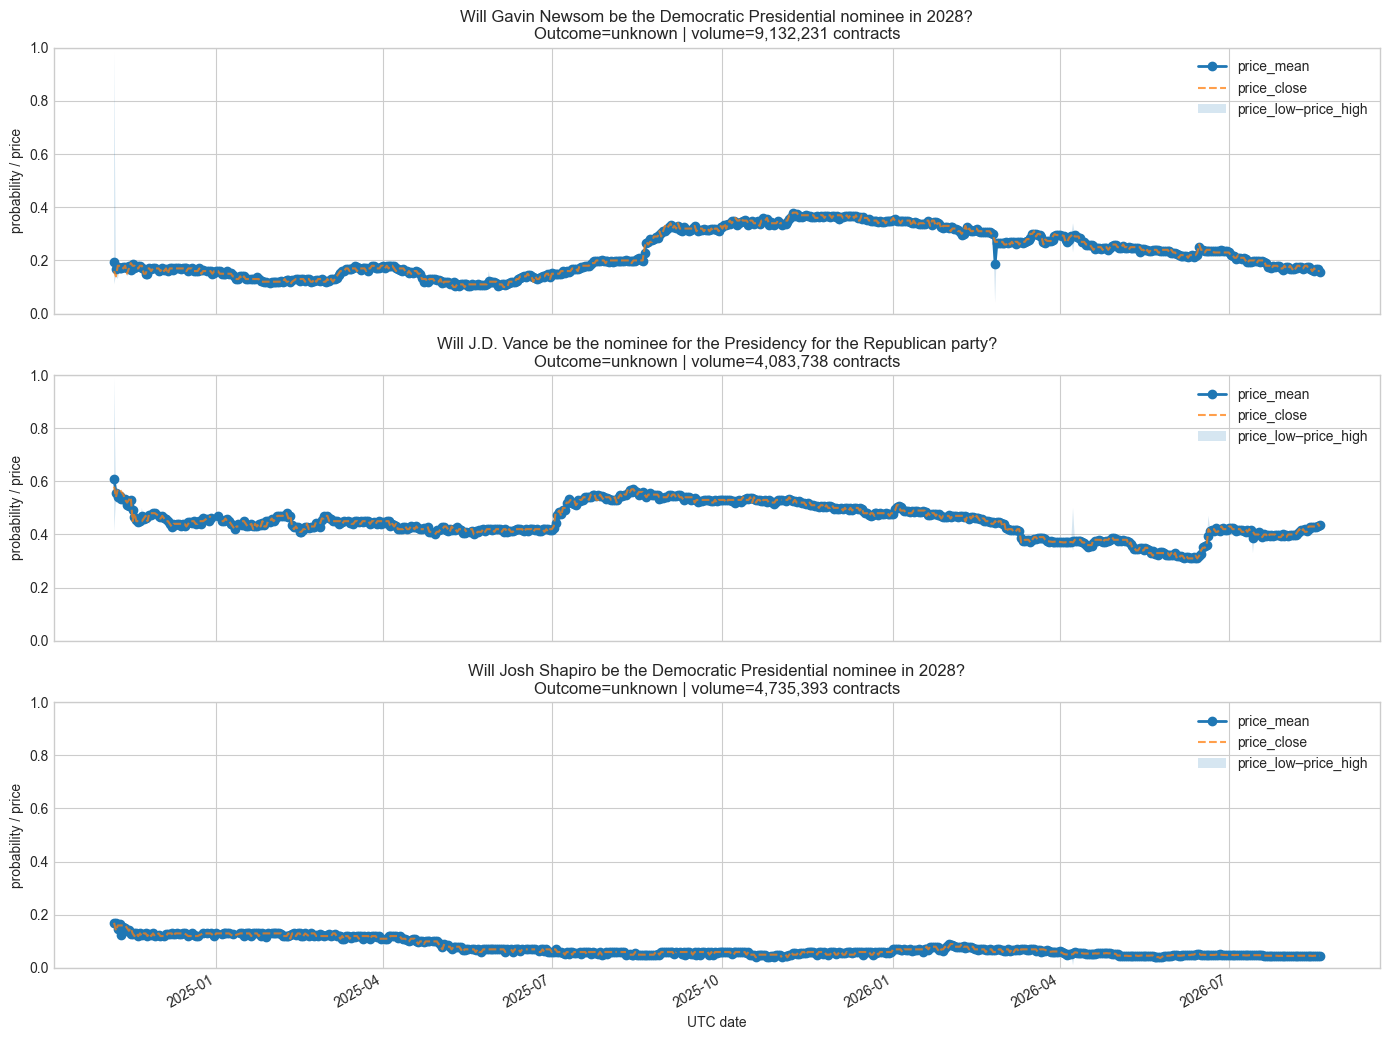

In [13]:
sample_ids = (
    market_activity.loc[market_activity["price_close_days"].gt(0)]
    .sort_values(["price_close_days", "total_volume"], ascending=False)
    .head(3)["market_id"]
    .tolist()
)

fig, axes = plt.subplots(
    len(sample_ids), 1, figsize=(14, 3.5 * len(sample_ids)), squeeze=False
)
for row_index, market_id in enumerate(sample_ids):
    plot_price_mean_for_market(
        market_id,
        ax=axes[row_index, 0],
        show=False,
    )
axes[-1, 0].set_xlabel("UTC date")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Next step: outcome-based research

For forecast timing, Brier Scores, calibration, and category comparisons, continue with `../../context_research/notebooks/research_script.ipynb`.